In [ ]:
!pip install datasets gensim -q

In [ ]:
from datasets import load_dataset

print('Loading the IMDb dataset...')
dataset = load_dataset('imdb')

print('\n--- Data Structure ---')
print(dataset)

print('\n--- Sample Instance from Training Set ---')
sample_index = 0
sample_text = dataset['train'][sample_index]['text']
sample_label = dataset['train'][sample_index]['label']

print(f'Text: {sample_text}')
print(f'Label: {sample_label}')

Loading the IMDb dataset...

--- Data Structure ---
DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

--- Sample Instance from Training Set ---
Text: I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really had to see this for myself.<br /><br />The plot is centered around a young Swedish drama student named Lena who wants to learn everything she can about life. In particular she wants to focus her attentions to making some sort of documentary on what the average Swede thought about certain political issues such

In [ ]:
import gensim.downloader as api
import torch
import numpy as np

print('\n--- Downloading static embedding model ---')
embedding_model = api.load('fasttext-wiki-news-subwords-300')
print('\n--- FastText model loaded successfully! ---')

def sentence_embedding(text: str, model, pool_type = 'mean'):
    tokens = text.lower().split()

    vectors = []
    for token in tokens:
        if token in model:
            vectors.append(model[token])

    if len(vectors) == 0:
        return torch.zeros(model.vector_size)

    vector_tensor = torch.tensor(np.array(vectors))
    if (pool_type == 'mean'):
        pooled_tensor = torch.mean(vector_tensor, dim=0)
    elif (pool_type == 'max'):
        pooled_tensor = torch.max(vector_tensor, dim=0)

    return pooled_tensor


--- Downloading static embedding model ---

--- FastText model loaded successfully! ---


In [ ]:
import torch.nn as nn

class SentimentNetwork(nn.Module):
    def __init__(self, input_dim=300, hidden_dim1=128, hidden_dim2=64, output_dim=2, dropout_rate=0.3):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim1, hidden_dim2)
        self.relu2 = nn.ReLU()
        self.out = nn.Linear(hidden_dim2, output_dim)
        self.dropout = nn.Dropout(p=dropout_rate)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout(x)

        logits = self.out(x)

        return logits

In [ ]:
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
from tqdm.auto import tqdm

train_dataset = dataset['train']
test_dataset = dataset['test']

class IMDBDataset(Dataset):
    def __init__(self, hf_dataset, embedding_model):
        self.data = hf_dataset
        self.embedding_model = embedding_model

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        text = self.data[index]['text']
        label = self.data[index]['label']

        vector = sentence_embedding(text, self.embedding_model, pool_type='mean')
        return vector, torch.tensor(label, dtype=torch.long)


train_data = IMDBDataset(train_dataset, embedding_model)
train_dataloader = DataLoader(train_data, batch_size=32, shuffle=True)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SentimentNetwork().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"Training on device: {device}")
print("\n--- Starting Training Loop ---")

epochs = 10
for epoch in range(epochs):
    model.train()

    total_loss = 0
    correct = 0
    total = 0

    progress_bar = tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    for batch_vectors, batch_labels in progress_bar:
        batch_vectors = batch_vectors.to(device)
        batch_labels = batch_labels.to(device)

        optimizer.zero_grad()
        outputs = model(batch_vectors)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        _, predicted = torch.max(outputs.data, 1)
        total += batch_labels.size(0)
        correct += (predicted == batch_labels).sum().item()

        progress_bar.set_postfix({'batch_loss': f"{loss.item():.4f}"})

    epoch_loss = total_loss / len(train_dataloader)
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.2f}%")

Training on device: cuda

--- Starting Training Loop ---


Epoch 1/10:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 1/10 | Loss: 0.5369 | Accuracy: 71.80%


Epoch 2/10:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 2/10 | Loss: 0.4242 | Accuracy: 81.00%


...

Epoch 8/10 | Loss: 0.3892 | Accuracy: 83.10%


Epoch 9/10:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 9/10 | Loss: 0.3903 | Accuracy: 83.12%


Epoch 10/10:   0%|          | 0/782 [00:00<?, ?it/s]

Epoch 10/10 | Loss: 0.3825 | Accuracy: 83.53%


In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

--- Starting Evaluation on Test Set ---

--- Evaluation Metrics ---
Accuracy  : 82.22%
Precision : 88.57%
Recall    : 74.00%
F1-Score  : 80.63%


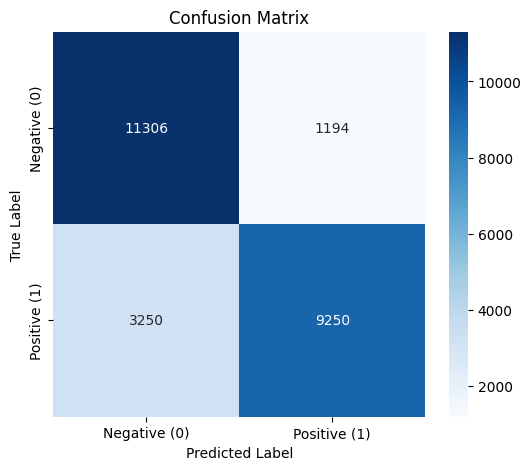

In [ ]:
test_data = IMDBDataset(test_dataset, embedding_model)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

model.eval()

all_preds = []
all_labels = []

print("--- Starting Evaluation on Test Set ---")

with torch.no_grad():
    for batch_vectors, batch_labels in test_loader:
        batch_vectors = batch_vectors.to(device)

        outputs = model(batch_vectors)

        _, predicted = torch.max(outputs.data, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(batch_labels.numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds)
rec = recall_score(all_labels, all_preds)
f1 = f1_score(all_labels, all_preds)

print(f"\n--- Evaluation Metrics ---")
print(f"Accuracy  : {acc * 100:.2f}%")
print(f"Precision : {prec * 100:.2f}%")
print(f"Recall    : {rec * 100:.2f}%")
print(f"F1-Score  : {f1 * 100:.2f}%")

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative (0)', 'Positive (1)'],
            yticklabels=['Negative (0)', 'Positive (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
import torch.nn.functional as F

def predict_review(text, model, embedding_model, device):
    model.eval()
    vector = sentence_embedding(text, embedding_model, pool_type='mean')
    vector = vector.unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(vector)
        probs = F.softmax(logits, dim=1)
        predicted_class = torch.argmax(probs, dim=1).item()
        confidence = probs[0][predicted_class].item() * 100

    sentiment = "Tích cực (Positive)" if predicted_class == 1 else "Tiêu cực (Negative)"

    print("-" * 50)
    print(f"Review: '{text}'")
    print(f"Result: {sentiment}")
    print(f"Confidence Score: {confidence:.2f}%")

In [ ]:
review = "I really love this film!"
predict = predict_review(review, model, embedding_model, device)

--------------------------------------------------
Review: 'I really love this film!'
Result: Tích cực (Positive)
Confidence Score: 99.99%
